# Walmart Weekly Sales Forecasting Project

## Executive Overview

Accurate sales forecasting is a critical component of retail analytics. In this project, we analyze historical Walmart sales data and develop predictive machine learning models to estimate weekly sales across different stores. The objective is to extract meaningful insights from the data and build a high-performing forecasting system that can assist in operational and strategic decision-making.


## Business Problem

Retail operations depend heavily on reliable demand forecasts. Inaccurate predictions may result in:

* **Overstocking**, increasing holding costs and wastage
* **Stockouts**, leading to lost sales and reduced customer satisfaction
* **Inefficient supply chain allocation**, affecting profitability

Therefore, building a robust predictive model for weekly sales is essential for inventory planning, pricing strategy, and supply chain optimization.

## Project Objectives

This project aims to:

* Perform comprehensive **data cleaning and preprocessing**
* Conduct detailed **Exploratory Data Analysis (EDA)** to uncover trends and patterns
* Identify and analyze **key features influencing sales**
* Develop and compare multiple **machine learning models**
* Apply **hyperparameter tuning** to improve model performance
* Design and implement an **Artificial Neural Network (ANN)**
* Evaluate and select the best-performing model using appropriate metrics

## Dataset Overview

The dataset contains historical weekly sales data for multiple Walmart stores, along with associated economic and environmental factors such as:

* Store ID
* Temperature
* Fuel Price
* Consumer Price Index (CPI)
* Unemployment Rate
* Holiday Flag
* Weekly Sales (Target Variable)

These variables allow us to model both store-level and macroeconomic influences on sales performance.



## Expected Deliverables

By the end of this project, we aim to:

* Develop a **high-accuracy predictive model** for weekly sales forecasting
* Compare traditional ML models and ANN-based approaches
* Extract actionable **business insights** from data analysis



## 1. Importing Required Libraries

| Library / Module            | Why It Is Imported (One-Line Purpose)                                                                |
| --------------------------- | ---------------------------------------------------------------------------------------------------- |
| `pandas`                    | Used for loading, cleaning, and manipulating structured tabular data (DataFrame operations).         |
| `numpy`                     | Provides numerical computation support and array-based mathematical operations for ML models.        |
| `matplotlib.pyplot`         | Used for creating basic plots such as line charts, scatter plots, and model performance graphs.      |
| `seaborn`                   | Used for advanced statistical visualizations like heatmaps, distributions, and correlation analysis. |
| `train_test_split`          | Splits dataset into training and testing sets to evaluate model generalization.                      |
| `GridSearchCV`              | Performs hyperparameter tuning using cross-validation to select optimal model parameters.            |
| `StandardScaler`            | Standardizes features by removing mean and scaling to unit variance for stable model training.       |
| `mean_squared_error`        | Measures average squared prediction error for regression evaluation.                                 |
| `mean_absolute_error`       | Measures average absolute prediction error, robust to outliers.                                      |
| `r2_score`                  | Evaluates goodness-of-fit by measuring proportion of variance explained by the model.                |
| `LinearRegression`          | Implements baseline linear regression model for predicting continuous targets.                       |
| `DecisionTreeRegressor`     | Builds non-linear regression model using tree-based recursive data splitting.                        |
| `RandomForestRegressor`     | Ensemble model combining multiple decision trees to reduce variance and improve accuracy.            |
| `GradientBoostingRegressor` | Boosting-based ensemble model that sequentially corrects previous errors for better performance.     |
| `RFE`                       | Performs recursive feature elimination to select most important predictive variables.                |
| `tensorflow`                | Deep learning framework used to build and train Artificial Neural Networks.                          |
| `Sequential`                | Keras API class used to construct neural networks layer-by-layer.                                    |
| `Dense`                     | Fully connected neural network layer used for learning weighted feature representations.             |
| `warnings`                  | Used to manage and suppress runtime warnings during execution.                                       |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
import tensorflow as tf
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.linear_model import LinearRegression
from tensorflow.keras.optimizers import SGD
from sklearn.feature_selection import RFE
from sklearn.model_selection import RandomizedSearchCV
import joblib
import warnings
import math
warnings.filterwarnings('ignore')

## 2. Loading and Understanding Dataset

In this step, we load the dataset and perform initial exploration.

Understanding the dataset is important before preprocessing because:
- It helps identify data types (numerical or categorical)
- Detects missing values
- Provides summary statistics
- Gives an overview of feature distributions

This step ensures that we clearly understand the structure and quality of the data before applying any transformations.

In [ ]:
def load_and_understand_data(path):
    # Load dataset
    df = pd.read_csv(path)
    print("Dataset Loaded Successfully")

    # Shape
    print("Shape of Dataset:", df.shape)

    # Data Types
    print("Data Types:\n")
    print(df.dtypes)
    print()

    # Missing Values
    print("Missing Values:\n")
    print(df.isnull().sum())

    # Statistical Summary
    print("Statistical Summary:\n")
    display(df.describe())

    # First few rows
    print("First 5 Rows:\n")
    display(df.head())

    return df

### Function: `load_and_understand_data(path)`

1. **Loads Dataset**
   Reads CSV file from the given path using `pd.read_csv()`.

2. **Prints Confirmation Message**
   Confirms dataset is successfully loaded.

3. **Displays Dataset Shape**
   Shows number of rows and columns using `df.shape`.

4. **Shows Data Types**
   Displays datatype of each column using `df.dtypes` (helps identify numeric vs categorical).

5. **Checks Missing Values**
   Counts null values per column using `df.isnull().sum()`.

6. **Displays Statistical Summary**
   Shows mean, std, min, max, quartiles using `df.describe()` for numerical columns.

7. **Shows First 5 Rows**
   Displays sample records using `df.head()` to understand structure.

8. **Returns DataFrame**
   Returns `df` so it can be used in further preprocessing or modeling steps.


In [ ]:
# Load dataset
df = load_and_understand_data("/content/Walmart.csv")

Dataset Loaded Successfully
Shape of Dataset: (6435, 8)
Data Types:

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Missing Values:

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
Statistical Summary:



,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


First 5 Rows:



,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## 3. Data Preprocessing and Feature Engineering

Data preprocessing is a fundamental stage in any machine learning workflow, as it enhances data quality and helps models learn more effectively.

In this stage, the following steps are carried out:

### 3.1. Date Conversion

The **'Date'** column is initially stored as a string. It is converted into a datetime format to enable extraction of time-related features.

### 3.2. Feature Engineering

Additional variables are derived from the **'Date'** column:

* **Year** – Used to analyze long-term or yearly trends
* **Month** – Helps capture seasonal patterns in sales
* **Week** – Allows analysis of weekly sales behavior

### 3.3. Categorical Handling

The **'Holiday_Flag'** column indicates whether a particular week includes a holiday. This variable is treated as a categorical feature in the model.

### 3.4. Feature Removal

After extracting the necessary information, the original **'Date'** column is removed to avoid redundancy.

Feature engineering strengthens model performance by transforming raw data into more informative and structured inputs.


In [ ]:
def preprocess_data(df):

    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
    df.drop('Date', axis=1, inplace=True)

    # Convert Holiday_Flag to categorical (optional but good)
    df['Holiday_Flag'] = df['Holiday_Flag'].astype('category')

    print("Preprocessing Completed")
    print("Updated Shape:", df.shape)

    return df

### Function: `preprocess_data(df)`

1. **Creates a Copy of Data**
   Uses `df.copy()` to avoid modifying the original dataset (prevents unintended side effects).

2. **Converts Date Column to Datetime**
   Transforms `'Date'` from string format (`%d-%m-%Y`) into proper datetime format using `pd.to_datetime()`.

3. **Extracts Year Feature**
   Creates a new column `'Year'` to capture yearly sales trends.

4. **Extracts Month Feature**
   Creates `'Month'` column to capture seasonal effects.

5. **Extracts Week Feature**
   Uses ISO calendar week (`dt.isocalendar().week`) to analyze weekly sales patterns.

6. **Removes Original Date Column**
   Drops `'Date'` column after extracting useful components to avoid redundancy.

7. **Converts Holiday_Flag to Categorical Type**
   Changes `'Holiday_Flag'` datatype to `category` for better memory usage and proper model interpretation.

8. **Prints Confirmation and Updated Shape**
   Displays preprocessing completion message and updated dataset dimensions.

9. **Returns Processed DataFrame**
   Outputs the cleaned and feature-engineered dataset for modeling.


In [ ]:
# Apply preprocessing
df = preprocess_data(df)

# Check output
df.head()

Preprocessing Completed
Updated Shape: (6435, 10)


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to examine underlying patterns, detect anomalies, and understand relationships within the dataset before model building.

### 4.1 Univariate Analysis

Univariate analysis involves examining one variable at a time to understand its individual characteristics.

In this step, we evaluate:

* Distribution of numerical features
* Descriptive statistical measures

This analysis helps identify:

* Data skewness and distribution shape
* Potential outliers
* Range and variability of each feature

By understanding each variable independently, we build a strong foundation for further multivariate analysis and modeling.


In [ ]:
def univariate_analysis(df):

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        plt.figure()
        sns.histplot(df[col], kde=True,color="r")
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

        print(f"Summary of {col}:")
        print(df[col].describe())
        print("="*50)


### Function: `univariate_analysis(df)`

1. **Selects Numerical Columns**
   Identifies all numeric features using `select_dtypes(include=np.number)` for analysis.

2. **Iterates Through Each Numeric Feature**
   Loops over every numerical column to analyze them individually.

3. **Plots Distribution Histogram**
   Uses `sns.histplot()` to visualize the distribution of each feature.

4. **Adds KDE Curve**
   Includes Kernel Density Estimate (KDE) to observe smooth distribution shape.

5. **Displays Plot Labels and Title**
   Sets title, x-axis, and y-axis labels for clarity.

6. **Shows Statistical Summary**
   Prints descriptive statistics using `describe()` (mean, std, min, max, quartiles).

7. **Separates Output for Readability**
   Prints a separator line after each feature’s analysis.



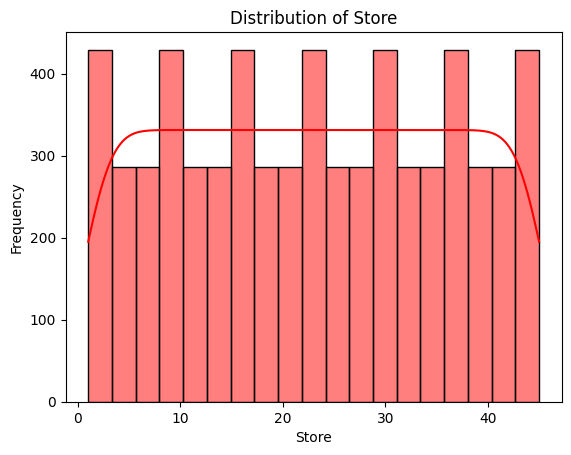

Summary of Store:
count    6435.000000
mean       23.000000
std        12.988182
min         1.000000
25%        12.000000
50%        23.000000
75%        34.000000
max        45.000000
Name: Store, dtype: float64


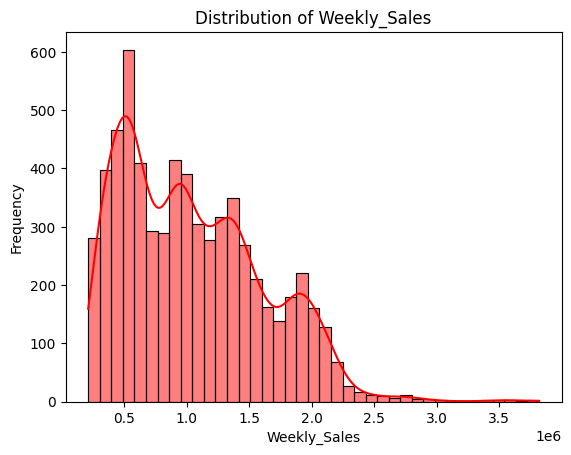

Summary of Weekly_Sales:
count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64


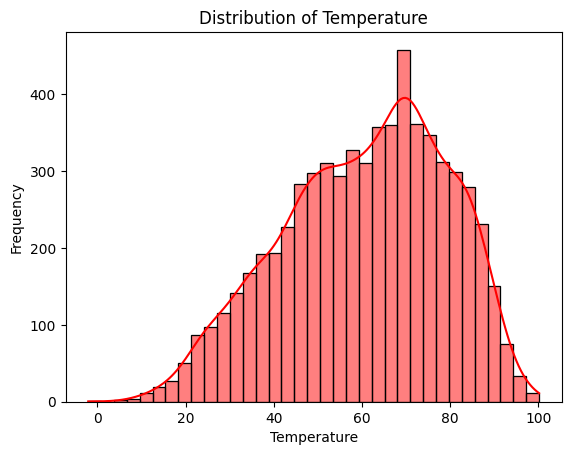

Summary of Temperature:
count    6435.000000
mean       60.663782
std        18.444933
min        -2.060000
25%        47.460000
50%        62.670000
75%        74.940000
max       100.140000
Name: Temperature, dtype: float64


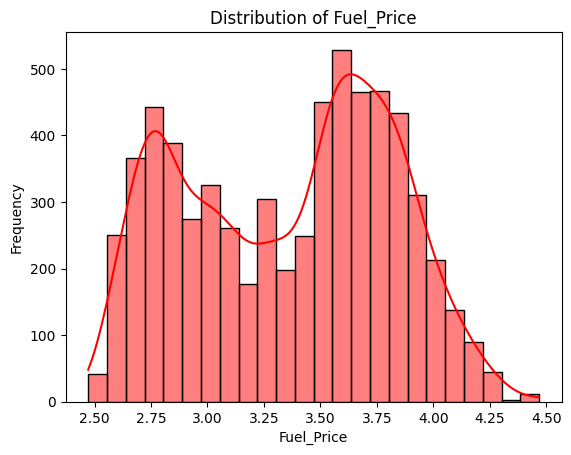

Summary of Fuel_Price:
count    6435.000000
mean        3.358607
std         0.459020
min         2.472000
25%         2.933000
50%         3.445000
75%         3.735000
max         4.468000
Name: Fuel_Price, dtype: float64


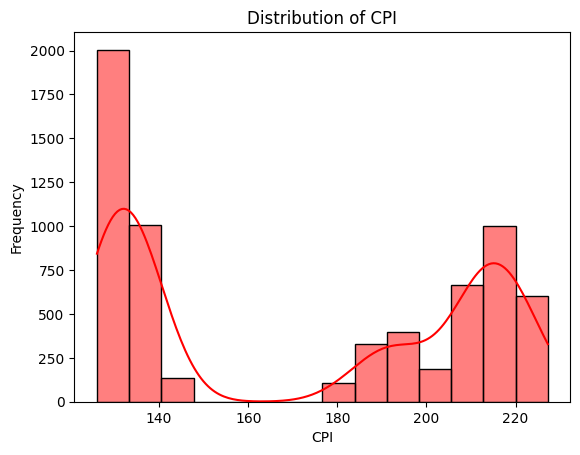

Summary of CPI:
count    6435.000000
mean      171.578394
std        39.356712
min       126.064000
25%       131.735000
50%       182.616521
75%       212.743293
max       227.232807
Name: CPI, dtype: float64


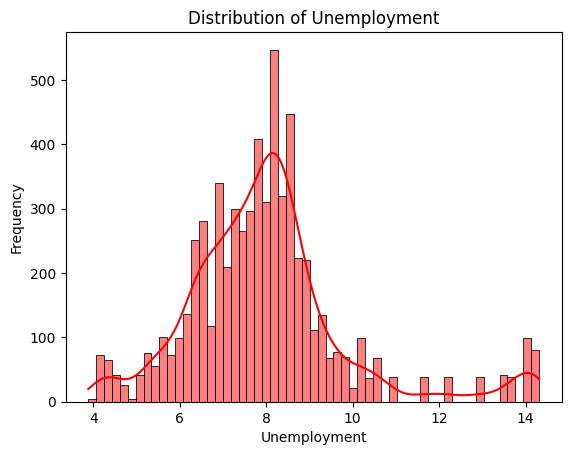

Summary of Unemployment:
count    6435.000000
mean        7.999151
std         1.875885
min         3.879000
25%         6.891000
50%         7.874000
75%         8.622000
max        14.313000
Name: Unemployment, dtype: float64


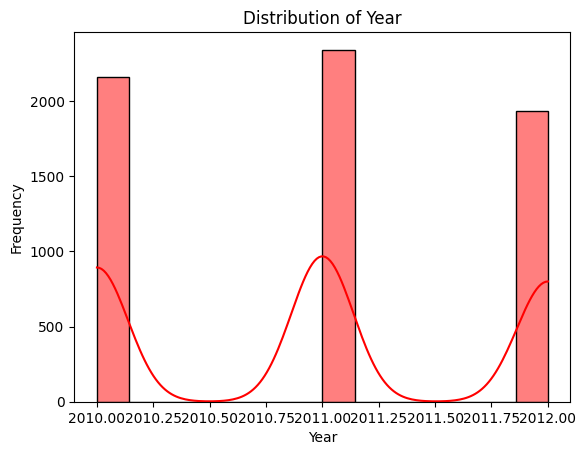

Summary of Year:
count    6435.000000
mean     2010.965035
std         0.797019
min      2010.000000
25%      2010.000000
50%      2011.000000
75%      2012.000000
max      2012.000000
Name: Year, dtype: float64


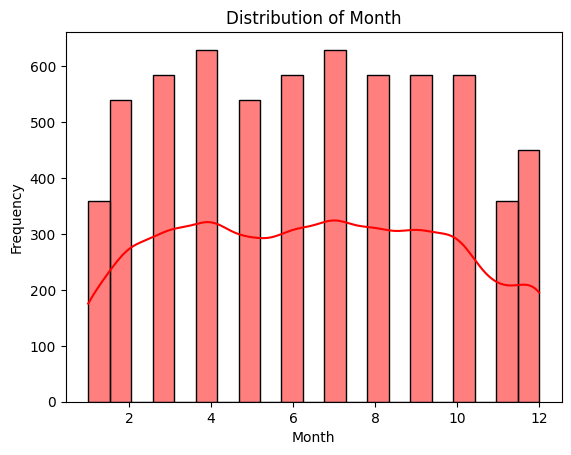

Summary of Month:
count    6435.000000
mean        6.447552
std         3.238308
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        12.000000
Name: Month, dtype: float64


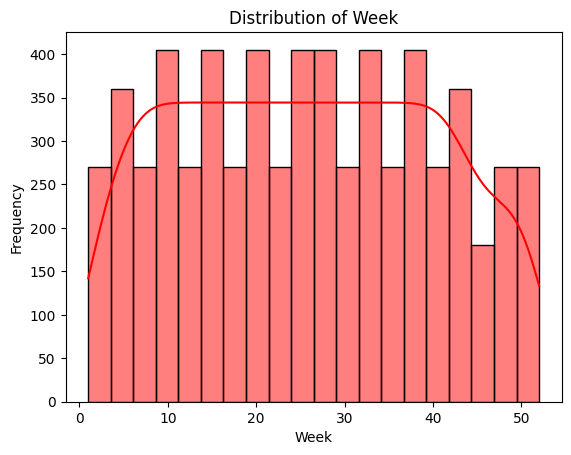

Summary of Week:
count    6435.000000
mean       25.818182
std        14.129201
min         1.000000
25%        14.000000
50%        26.000000
75%        38.000000
max        52.000000
Name: Week, dtype: float64


In [ ]:
# Run
univariate_analysis(df)

### 4.2 Bivariate Analysis

Bivariate analysis examines the relationship between two variables to understand how they interact with each other.

In this stage, we focus on:

* The relationship between independent features and the target variable (**Weekly_Sales**)
* The correlation among input features

This analysis helps to:

* Identify variables that significantly influence sales
* Detect strong positive or negative relationships
* Understand multicollinearity between predictors

By studying these relationships, we can select meaningful features and improve model performance.


In [ ]:
def bivariate_analysis(df, target='Weekly_Sales'):

    numeric_cols = df.select_dtypes(include=np.number).columns
    feature_cols = [col for col in numeric_cols if col != target]

    n_cols = 2   # number of subplot columns
    n_rows = int(np.ceil(len(feature_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(feature_cols):
        sns.scatterplot(x=df[col], y=df[target], ax=axes[i])
        axes[i].set_title(f'{col} vs {target}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)

    # Remove empty subplots (if any)
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


    # Correlation Heatmap

    plt.figure(figsize=(10,8))
    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()


    print("\nCorrelation with Target (Sorted):\n")

    target_corr = corr_matrix[target].sort_values(ascending=False)
    print(target_corr)

### Function: `bivariate_analysis(df, target='Weekly_Sales')`

1. **Selects Numerical Columns**
   Identifies all numeric features in the dataset.

2. **Separates Target Variable**
   Removes the target column (`Weekly_Sales`) from feature list.

3. **Creates Subplots Grid**
   Arranges scatter plots side-by-side (2 per row) for better visualization.

4. **Plots Feature vs Target Scatter Plots**
   Displays relationship between each numeric feature and the target variable.

5. **Removes Extra Empty Plots**
   Deletes unused subplot spaces (if total features are odd).

6. **Displays Correlation Heatmap**
   Shows full correlation matrix using heatmap for feature relationships.

7. **Prints Sorted Correlation Values**
   Displays correlation of each feature with target in descending order.


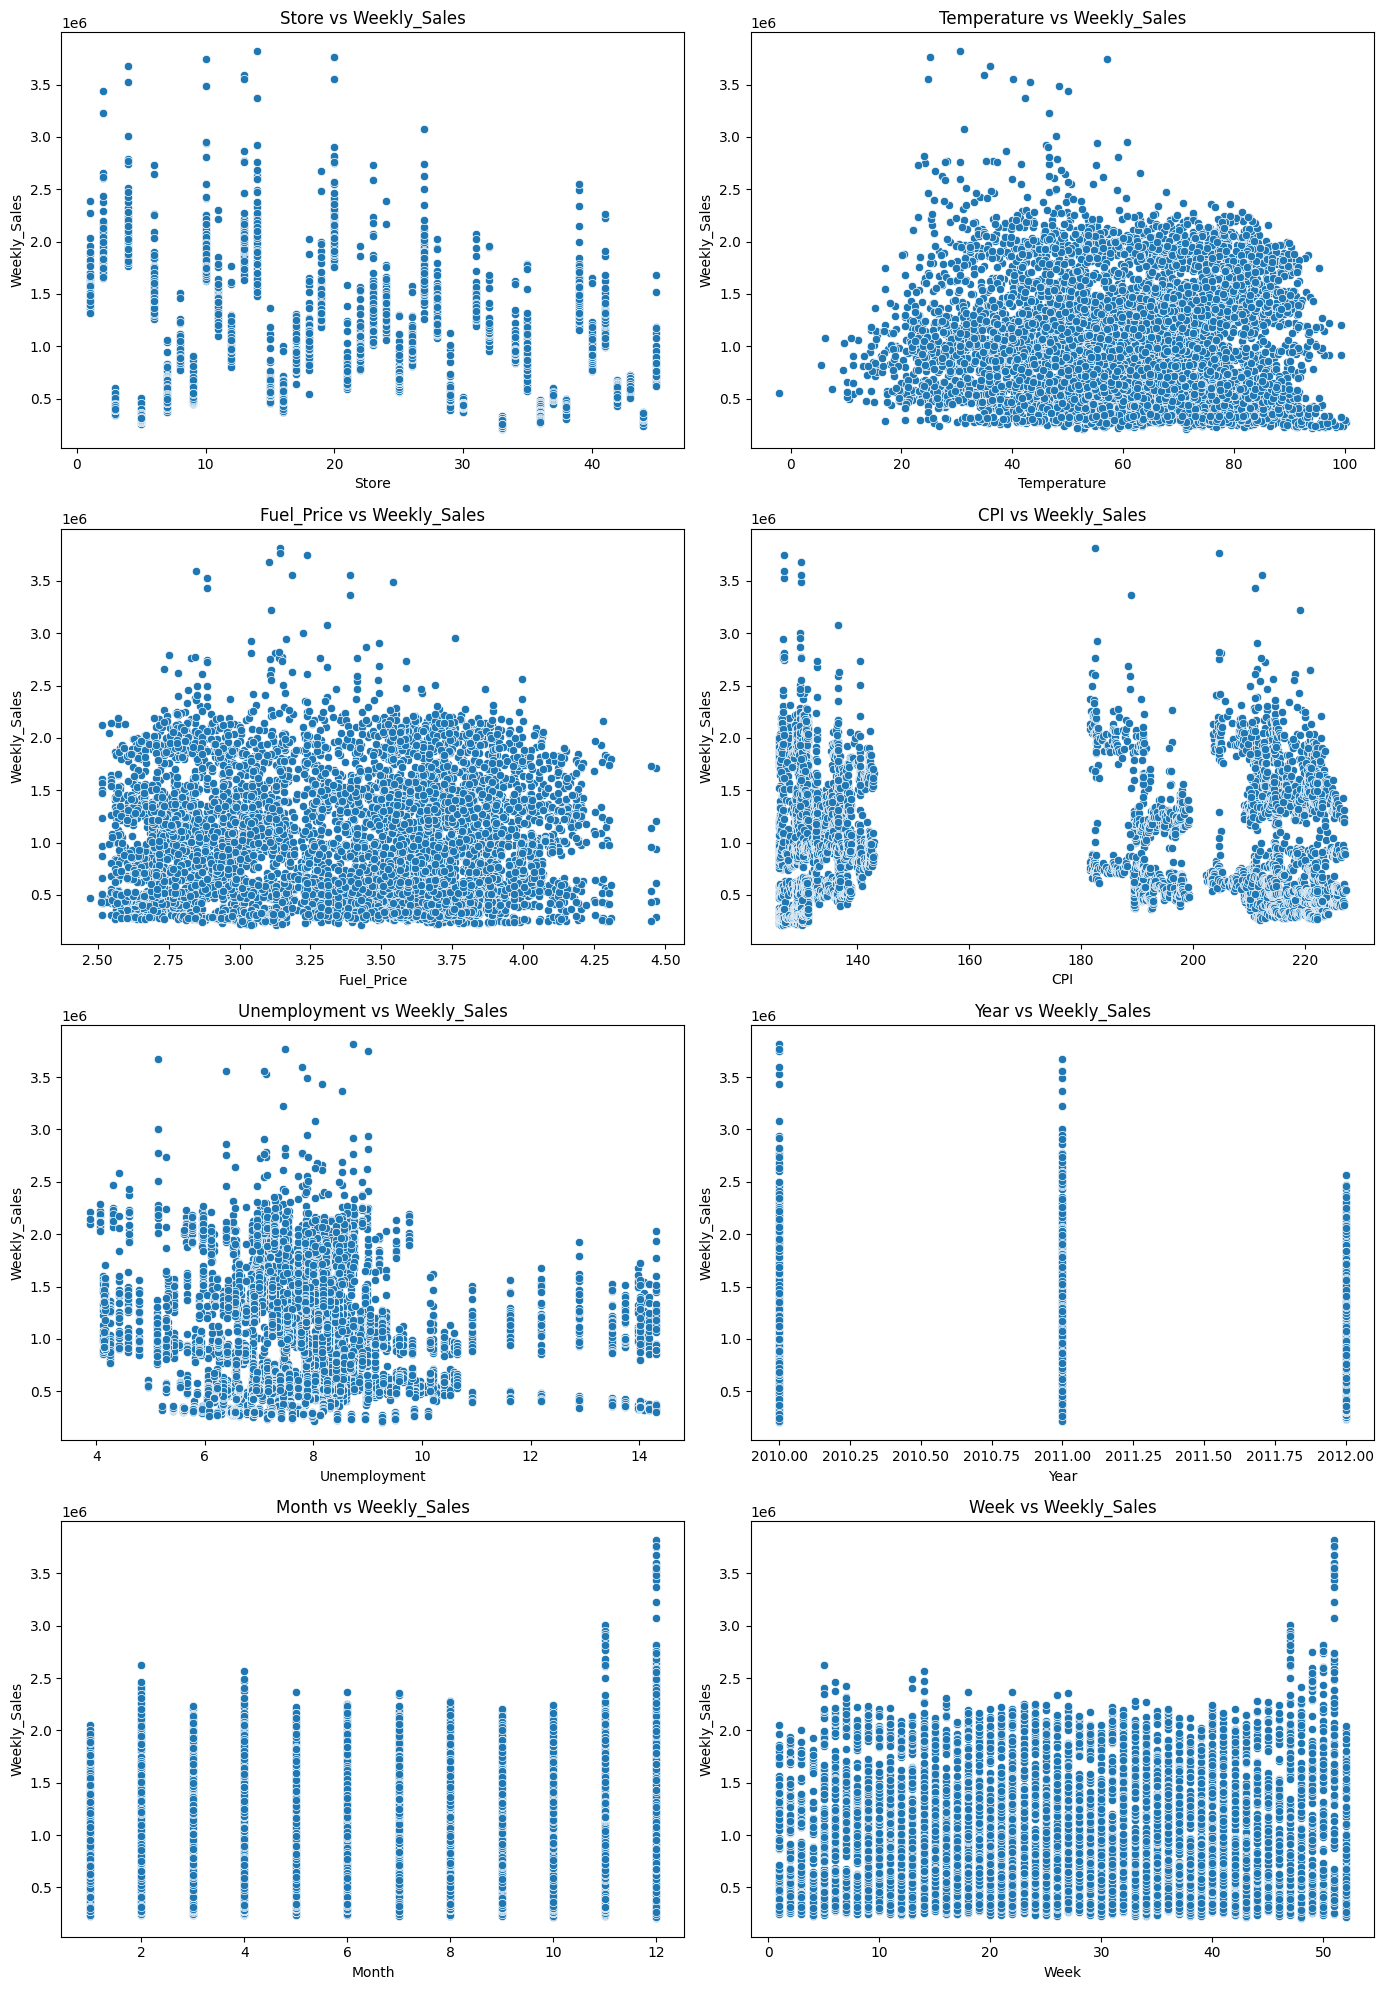

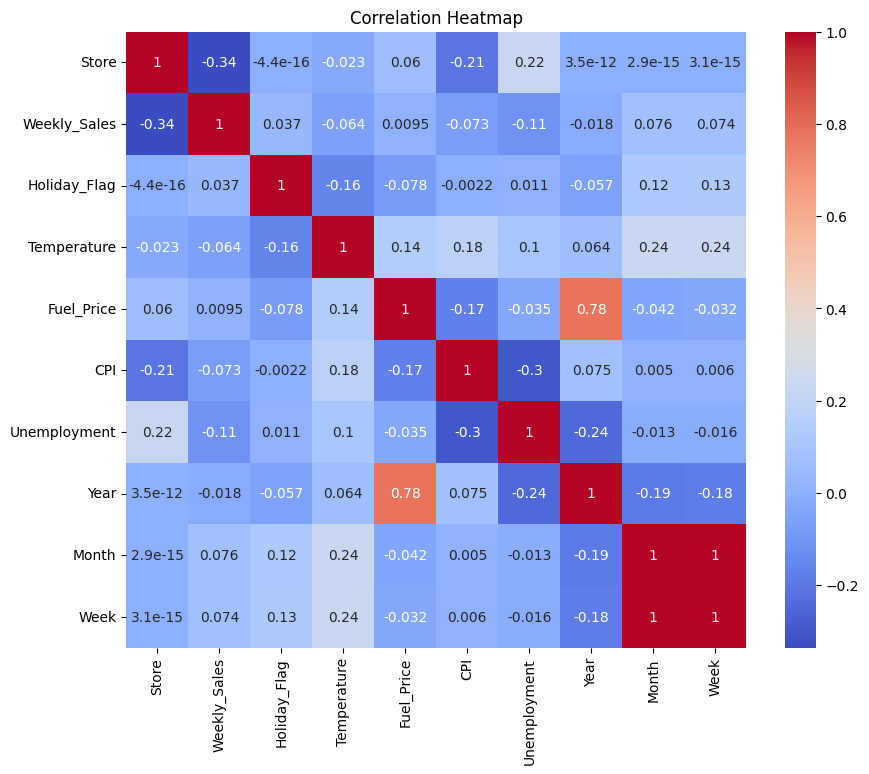


Correlation with Target (Sorted):

Weekly_Sales    1.000000
Month           0.076143
Week            0.074211
Holiday_Flag    0.036891
Fuel_Price      0.009464
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64


In [ ]:
bivariate_analysis(df)

* Sales show **strong seasonality**, with clear spikes in November–December (holiday impact).
* **Store-level variation is high**, meaning some stores consistently outperform others.
* Macro variables (CPI, Fuel Price, Temperature) show **very weak correlation** with sales.
* Slight negative relationship between **Unemployment and Sales**.
* Fuel Price is highly correlated with Year → possible **multicollinearity risk**.
* Overall, sales are driven more by **seasonality and store effects** than macro factors.


### 4.3 Categorical Feature Analysis

We analyze categorical variables to understand their impact on sales.

In this dataset, Holiday_Flag is a categorical variable indicating whether the week is a holiday.

In [ ]:
def categorical_analysis(df, target='Weekly_Sales'):

    categorical_cols = df.select_dtypes(include=['category', 'object']).columns

    for i, col in enumerate(categorical_cols, 1):

        sns.boxplot(
            x=df[col],
            y=df[target],
            palette="Set2"
        )

        plt.title(f'{col} vs {target}', fontsize=13, fontweight='bold')
        plt.xticks(rotation=45)
        plt.xlabel(col)
        plt.ylabel(target)

    plt.tight_layout()
    plt.show()



##  Function Insights – `categorical_analysis()`

* Automatically selects all **categorical features** from the dataset.
* Loops through each category using `enumerate()`.
* Generates a **boxplot** of each categorical variable vs `Weekly_Sales`.
* Boxplot shows **median, quartiles, spread, and outliers**.
* Rotates x-labels to improve readability.
* Adds proper **titles and axis labels** for clarity.
* Uses `tight_layout()` to avoid overlapping elements.


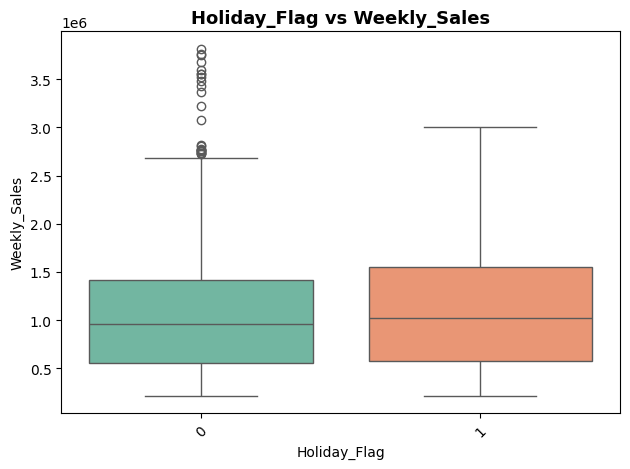

In [ ]:
# Run
categorical_analysis(df)

## 4.4 Key Insights from EDA

Based on the exploratory data analysis, the following key insights were derived:

### 1. Distribution of Weekly Sales
The distribution of Weekly_Sales is right-skewed, indicating that most stores have moderate sales while a few observations have extremely high sales. This suggests the presence of outliers and high-performing stores.

### 2. Presence of Outliers in Sales
From the distribution and boxplots, it is evident that there are several extreme values in Weekly_Sales. These outliers may significantly influence model performance, especially linear models.

### 3. Weak Correlation with Target Variable
The correlation heatmap shows that most independent variables have very weak correlation with Weekly_Sales. This indicates that sales are influenced by complex, non-linear relationships rather than simple linear patterns.

### 4. Store Feature Influence
The Store variable shows a moderate negative correlation with Weekly_Sales (-0.34), indicating that sales vary significantly across different stores. This suggests that store-specific characteristics play an important role in sales performance.

### 5. Holiday Impact on Sales
The boxplot of Holiday_Flag vs Weekly_Sales shows that median sales during holidays are slightly higher than non-holiday periods. However, the overlap between distributions indicates that holidays do not have a very strong impact on sales.

### 6. Economic Factors Impact
Features like CPI and Unemployment show very weak correlation with Weekly_Sales, suggesting that macroeconomic factors have limited direct influence on weekly store sales in this dataset.

### 7. Temperature and Seasonal Effects
Temperature shows a very weak relationship with Weekly_Sales, indicating that seasonal effects exist but are not strong predictors individually.

### 8. Multicollinearity in Time Features
The correlation heatmap shows that Month and Week are highly correlated (close to 1). This indicates redundancy, and one of these features may need to be removed during feature selection.

### 9. Relationship Between Fuel Price and Year
Fuel_Price and Year show strong positive correlation (0.78), indicating that fuel prices increase over time. However, their direct impact on sales is minimal.

### 10. Overall Insight
Since most features show weak linear relationships with the target variable, non-linear models like Random Forest and Gradient Boosting are expected to perform better than Linear Regression.

## 5. Outlier Detection and Handling

Outliers are data points that lie far away from the majority of observations.

They can distort statistical analysis and negatively affect model performance, particularly in linear models where extreme values influence coefficients.

In this stage:

* Outliers are identified using **boxplots and the IQR (Interquartile Range) method**
* A decision is made to remove or retain them based on domain knowledge

For retail sales data, unusually high values may correspond to **seasonal peaks or holiday demand**, so they should be evaluated carefully before elimination.


In [ ]:
def detect_outliers(df):

    numeric_cols = df.select_dtypes(include=np.number).columns[:9]  # Take first 9 columns

    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):

        sns.boxplot(
            x=df[col],
            ax=axes[i],
            color='red'   # Change color here
        )

        axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')

    # Remove empty plots if less than 9 columns
    for j in range(len(numeric_cols), 9):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


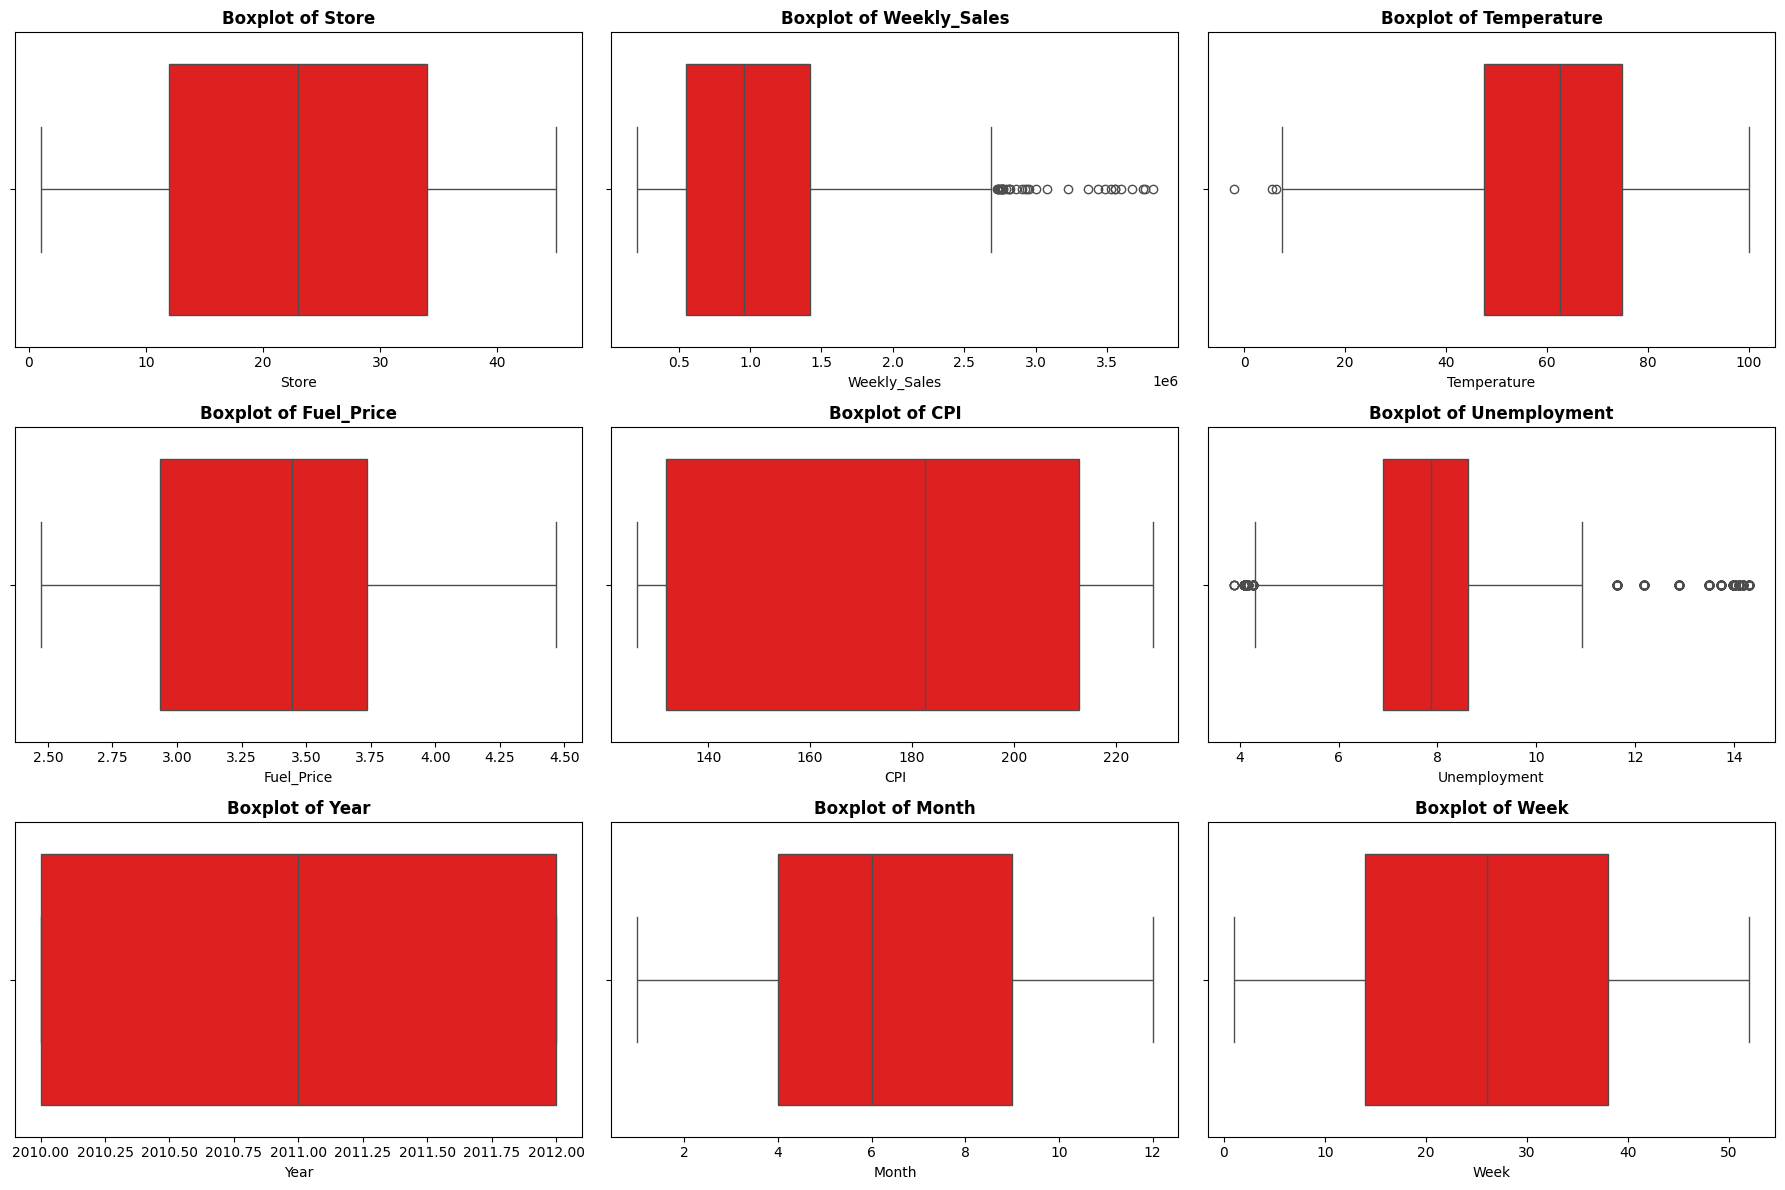

In [ ]:
# Run
detect_outliers(df)

## Function Explanation: `detect_outliers(df)`

* Selects the first 9 numerical columns from the dataset using `select_dtypes(include=np.number)`.
* Creates a 3×3 subplot grid using `plt.subplots()` to display multiple boxplots in a single figure.
* Flattens the axes array so each subplot can be accessed using a simple loop.
* Iterates through each numeric column and plots a **boxplot** for that feature.
* The boxplot visually highlights median, quartiles, spread, and potential outliers.
* Sets a bold title for each subplot indicating the column name.
* Removes unused subplot spaces if there are fewer than 9 numeric columns.
* Uses `tight_layout()` to prevent overlapping between plots and ensures clean visualization.


In [ ]:
def calculate_outliers(df):

    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

        outlier_summary[col] = outliers

    return pd.DataFrame(outlier_summary.items(), columns=['Feature', 'Outlier_Count'])


In [ ]:
# Run
calculate_outliers(df)

,Feature,Outlier_Count
0,Store,0
1,Weekly_Sales,34
2,Temperature,3
3,Fuel_Price,0
4,CPI,0
5,Unemployment,481
6,Year,0
7,Month,0
8,Week,0


## Function Explanation: `calculate_outliers(df)`

* Initializes an empty dictionary `outlier_summary` to store outlier counts for each feature.
* Selects all numerical columns from the dataset using `select_dtypes(include=np.number)`.
* Iterates through each numeric column.
* Computes the first quartile (Q1) and third quartile (Q3).
* Calculates the Interquartile Range (IQR = Q3 − Q1).
* Defines lower and upper bounds using the IQR rule:
$
  [
  \text{Lower} = Q1 - 1.5 \times IQR, \quad
  \text{Upper} = Q3 + 1.5 \times IQR
  ]
$

* Counts the number of values lying outside these bounds (outliers).
* Stores the outlier count for each feature in the dictionary.
* Returns the result as a DataFrame with two columns: **Feature** and **Outlier_Count**.


## 5.1 Outlier Treatment Strategy

Based on the outlier assessment, the following actions were taken:

### 1. Weekly_Sales

Extreme values in **Weekly_Sales** correspond to genuine high-demand periods such as holidays or promotional events. Eliminating these observations would remove meaningful business signals.
Hence, outliers in the target variable are retained.

### 2. Unemployment

A noticeable number of extreme values were identified in the **Unemployment** feature. These may disproportionately influence model training and lead to biased estimates.
Therefore, winsorization (capping at defined bounds) is applied to control their effect.

### 3. Temperature

Only a minimal number of extreme values were detected in **Temperature**, indicating no material impact.
Thus, no corrective treatment is implemented.

### Final Decision

* Outliers in the target variable are preserved to maintain business relevance.
* Outliers in input features are handled selectively based on their potential impact on model performance.


In [ ]:
def cap_outliers(df, columns):

    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])

    print("Outliers capped successfully")
    return df

## Function Explanation: `cap_outliers(df, columns)`

* Creates a copy of the original DataFrame to avoid modifying it directly.
* Iterates through the specified numeric columns provided in the `columns` list.
* Computes Q1 (25th percentile) and Q3 (75th percentile) for each column.
* Calculates the Interquartile Range (IQR = Q3 − Q1).
* Determines lower and upper bounds using the IQR rule:
$
  [
  \text{Lower} = Q1 - 1.5 \times IQR, \quad
  \text{Upper} = Q3 + 1.5 \times IQR
  ]
  $
* Applies capping (winsorization):

  * Values below the lower bound are replaced with the lower bound.
  * Values above the upper bound are replaced with the upper bound.
* Prints a confirmation message after processing.
* Returns the updated DataFrame with capped outliers.

**Purpose:**
To reduce the impact of extreme feature values while preserving the overall distribution and dataset size.


In [ ]:
df = cap_outliers(df,['Unemployment'])

Outliers capped successfully


In [ ]:
calculate_outliers(df)

,Feature,Outlier_Count
0,Store,0
1,Weekly_Sales,34
2,Temperature,3
3,Fuel_Price,0
4,CPI,0
5,Unemployment,0
6,Year,0
7,Month,0
8,Week,0


## 6. Feature Selection and Multicollinearity

Feature selection involves identifying and retaining the most informative variables for model development while excluding redundant or irrelevant ones.

Multicollinearity arises when two or more independent variables are strongly correlated. This can inflate coefficient estimates and reduce the reliability of linear models.

To assess multicollinearity, the **Variance Inflation Factor (VIF)** is calculated:

* A VIF value greater than 10 typically signals high multicollinearity.
* Variables with high VIF should be considered for removal or adjustment.

Addressing multicollinearity enhances model robustness, improves interpretability, and leads to more stable parameter estimates.


In [ ]:
def calculate_vif(df, target='Weekly_Sales'):

    X = df.drop(columns=[target])

    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_data

# Run
vif_df = calculate_vif(df)
vif_df

,Feature,VIF
0,Store,4.541948
1,Holiday_Flag,1.143029
2,Temperature,14.418699
3,Fuel_Price,61.031028
4,CPI,24.579899
5,Unemployment,33.086711
6,Year,159.461803
7,Month,630.170643
8,Week,551.076077


## Function Explanation: `calculate_vif(df, target='Weekly_Sales')`

* Creates feature matrix **X** by removing the target variable (`Weekly_Sales`) from the dataset.
* Initializes an empty DataFrame `vif_data` to store VIF results.
* Stores all feature names in the `Feature` column.
* Computes the **Variance Inflation Factor (VIF)** for each feature using:
  
  $
  [
  VIF_i = \frac{1}{1 - R_i^2}
  ]
  $

  
  where (R_i^2) is obtained by regressing that feature against all other features.
* Uses a list comprehension to calculate VIF for every column in `X`.
* Returns a DataFrame containing each feature and its corresponding VIF value.

### Purpose

To detect multicollinearity among independent variables and identify features that may inflate variance and destabilize linear models.


## 6.1 Multicollinearity Treatment

The Variance Inflation Factor (VIF) analysis revealed that several features have very high multicollinearity.

### Features Removed:
- Year
- Month
- Week

These features showed extremely high VIF values (>500), indicating strong correlation among them. Since all three represent time-related information, they are redundant. Removing them helps reduce multicollinearity and improves model stability.

### Features Retained:
- Temperature
- Fuel_Price
- CPI
- Unemployment

Although these features have moderately high VIF values, they represent different real-world factors such as economic conditions and environmental variables. Tree-based models can handle multicollinearity, so these features are retained.

### Final Decision:
Redundant time-based features are removed, while meaningful variables are retained to preserve important information.

In [ ]:
def remove_multicollinearity(df):

    df = df.copy()

    # Drop high VIF features
    df.drop(columns=['Year', 'Month', 'Week'], inplace=True)

    print("Removed features: Year, Month, Week")
    print("New Shape:", df.shape)

    return df


## Function Explanation: `remove_multicollinearity(df)`

* Creates a copy of the original DataFrame to prevent modifying the source data directly.
* Removes the columns `Year`, `Month`, and `Week` using the `drop()` method.
* These features are assumed to have high multicollinearity (typically identified using VIF or correlation analysis).
* Prints the names of the removed features for transparency.
* Displays the new dataset shape after column removal.
* Returns the updated DataFrame with reduced feature set.

### Purpose

To reduce multicollinearity by eliminating redundant time-based features, thereby improving model stability and interpretability—particularly for linear regression models.


In [ ]:
# Apply
df = remove_multicollinearity(df)

df.head()

Removed features: Year, Month, Week
New Shape: (6435, 7)


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,1554806.68,0,46.50,2.625,211.350143,8.106


## 6.2 Feature Selection using RFE

Recursive Feature Elimination (RFE) is a feature selection technique that iteratively removes the least important features based on model performance. By eliminating less relevant features step by step, it helps enhance model accuracy and minimize overfitting.


In [ ]:
def select_features_rfe(df, target='Weekly_Sales', n_features=5):

    X = df.drop(columns=[target])
    y = df[target]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    rfe = RFE(model, n_features_to_select=n_features)

    rfe.fit(X_scaled, y)

    selected_features = X.columns[rfe.support_]

    return list(selected_features)

## Function Explanation: `select_features_rfe(df, target='Weekly_Sales', n_features=5)`

* Separates the dataset into independent variables (**X**) and the target variable (**y**) by dropping `Weekly_Sales` from the feature set.
* Applies **StandardScaler** to normalize the feature matrix, ensuring all variables are on the same scale before model fitting.
* Initializes a **Linear Regression** model as the base estimator.
* Uses **Recursive Feature Elimination (RFE)** to iteratively remove less important features based on model coefficients.
* Selects the top `n_features` that contribute most to predicting the target variable.
* Identifies selected features using `rfe.support_`, which returns a boolean mask of chosen features.
* Returns the final list of selected feature names.

### Purpose

To reduce dimensionality by retaining only the most relevant predictors for modeling, improving interpretability and potentially enhancing model performance.


In [ ]:
select_features_rfe(df)

['Store', 'Holiday_Flag', 'Temperature', 'CPI', 'Unemployment']

## 7. Data Splitting and Feature Scaling

Prior to model development, the dataset is partitioned into training and testing subsets.

* The training set is used to fit and learn model parameters.
* The testing set is reserved for evaluating how well the model generalizes to unseen data.

### Feature Scaling

Feature scaling is performed to standardize the input variables, which is particularly important for algorithms such as Linear Regression and Artificial Neural Networks.

**StandardScaler** is applied to rescale features so that:

* The mean of each feature becomes 0
* The standard deviation becomes 1

This ensures consistent feature magnitude and improves model stability and convergence.


In [ ]:
def split_data(df, target='Weekly_Sales'):

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("Training Shape:", X_train.shape)
    print("Testing Shape:", X_test.shape)

    return X_train, X_test, y_train, y_test


In [ ]:
target='Weekly_Sales'
X = df.drop(columns=[target])
y = df[target]


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.20)

## Function Explanation: `split_data(df, target='Weekly_Sales')`

* Separates the dataset into independent variables (**X**) by dropping the target column and assigns the target variable (**y**) separately.
* Uses `train_test_split()` to randomly divide the dataset into training and testing sets.
* Allocates 80% of the data for model training and 20% for evaluation using `test_size=0.2`.
* Sets `random_state=42` to ensure reproducibility of the split across multiple runs.
* Prints the shapes of the training and testing feature matrices to verify correct data partitioning.
* Returns four outputs: `X_train`, `X_test`, `y_train`, and `y_test`.

### Purpose

To create separate datasets for model training and performance evaluation, ensuring unbiased assessment on unseen data.


## 8. Model Development

A pipeline-based training function is implemented to systematically train and compare multiple regression algorithms. This approach ensures consistent preprocessing (such as feature scaling where required) and structured model evaluation.

The function iterates through a dictionary of models, fits each model on the training data, generates predictions on the test data, and computes evaluation metrics for comparison.

The models included are:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Support Vector Regressor (SVR)
* K-Nearest Neighbors (KNN)
* Decision Tree Regressor
* Random Forest Regressor
* Gradient Boosting Regressor
* Extra Trees Regressor

### Evaluation Metrics

Each model is assessed using the following metrics:

* **RMSE (Root Mean Squared Error):** Reflects the standard deviation of prediction errors and penalizes larger errors more heavily.
* **MAE (Mean Absolute Error):** Measures the average absolute difference between predicted and actual values.
* **R² Score:** Represents the proportion of variance in the target variable explained by the model.

Models are ranked based on performance, where lower RMSE and MAE, combined with a higher R² score, indicate stronger predictive capability.


In [ ]:
def train_models_pipeline(X_train, X_test, y_train, y_test):

    models = {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),

        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),

        "Lasso": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso())
        ]),

        "SVR": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor())
        ]),

        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "Extra Trees": ExtraTreesRegressor(random_state=42)
    }

    results = []
    trained_models = {}

    for name, model in models.items():

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)

        results.append({
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        trained_models[name] = model

    results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

    return results_df, trained_models

## Function Explanation: `train_models_pipeline(X_train, X_test, y_train, y_test)`

* Defines a dictionary of regression models, including both linear and tree-based algorithms.
* Uses **Pipeline** for models that require feature scaling (Linear Regression, Ridge, Lasso, SVR, KNN).
* Keeps tree-based models (Decision Tree, Random Forest, Gradient Boosting, Extra Trees) without scaling, as they are scale-invariant.
* Iterates through each model in the dictionary.
* Fits the model using the training dataset (`X_train`, `y_train`).
* Generates predictions on the testing dataset (`X_test`).
* Computes evaluation metrics:

  * **RMSE** to measure prediction error magnitude
  * **MAE** to calculate average absolute error
  * **R² score** to assess explained variance
* Stores model performance metrics in a list of dictionaries.
* Converts the results into a DataFrame and sorts models by highest R² score.
* Returns the sorted performance comparison table.

### Purpose

To systematically train multiple regression models, evaluate their predictive performance, and identify the best-performing algorithm for the dataset.


In [ ]:
def run_full_pipeline(df, target='Weekly_Sales'):

    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    results = train_models_pipeline(X_train, X_test, y_train, y_test)

    return results

In [ ]:
results_df = run_full_pipeline(df)
results_df

(               Model           RMSE            MAE        R2
 8        Extra Trees  144762.340197   75632.371591  0.934950
 6      Random Forest  147338.050396   76923.035895  0.932615
 5      Decision Tree  194800.094508  100595.654926  0.882208
 7  Gradient Boosting  200974.200293  138905.092259  0.874623
 4                KNN  313853.590652  196803.081714  0.694233
 2              Lasso  524367.944345  434013.336536  0.146491
 0  Linear Regression  524367.994736  434013.347828  0.146491
 1              Ridge  524369.205852  434016.660407  0.146487
 3                SVR  575584.241701  471101.580727 -0.028380,
 {'Linear Regression': Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())]),
  'Ridge': Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())]),
  'Lasso': Pipeline(steps=[('scaler', StandardScaler()), ('model', Lasso())]),
  'SVR': Pipeline(steps=[('scaler', StandardScaler()), ('model', SVR())]),
  'KNN': Pipeline(steps=[('scaler', Standard

In [ ]:
results_df, trained_models = train_models_pipeline(X_train, X_test, y_train, y_test)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:")
best_model_name

Best Model:


'Extra Trees'

## 8.1 Model Performance Analysis

The performance of multiple regression models was evaluated using RMSE, MAE, and R² score.

### Model Comparison (Based on Results)

| Model                  | Performance Summary                    |
| ---------------------- | -------------------------------------- |
| Linear / Ridge / Lasso | Very low R² (~0.14), high error        |
| SVR                    | Poor performance (negative R²)         |
| KNN                    | Moderate performance (R² ≈ 0.69)       |
| Decision Tree          | Strong performance (R² ≈ 0.88)         |
| Gradient Boosting      | Strong performance (R² ≈ 0.87)         |
| Random Forest          | Excellent performance (R² ≈ 0.93)      |
| Extra Trees            | Best overall performance (R² ≈ 0.9349) |



### Observations

1. Linear-based models performed poorly, indicating the dataset does not follow a simple linear structure.
2. Tree-based models significantly outperformed linear models, confirming strong non-linear patterns.
3. Extra Trees achieved:

   * Lowest RMSE
   * Lowest MAE
   * Highest R² score (~0.93)
4. Random Forest performed almost equally well, slightly below Extra Trees.


### Conclusion

Extra Trees Regressor is selected as the best-performing model due to its highest R² score and lowest prediction error.

Its ensemble structure effectively captures non-linear relationships and reduces variance, making it the most suitable model for this dataset.




## 8.2 Overfitting and Underfitting Analysis

Overfitting occurs when a model performs well on training data but poorly on testing data.

Underfitting occurs when a model performs poorly on both training and testing data.

To detect this, we compare training and testing performance.

In [ ]:
def check_overfitting(model, X_train, X_test, y_train, y_test):

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    r2_gap = train_r2 - test_r2
    rmse_ratio = test_rmse / train_rmse

    print(f"Training R2: {train_r2:.4f}")
    print(f"Testing R2: {test_r2:.4f}")
    print(f"R2 Gap: {r2_gap:.4f}")
    print(f"Train RMSE: {train_rmse:.2f}")
    print(f"Test RMSE: {test_rmse:.2f}")

    if r2_gap > 0.15 or rmse_ratio > 1.35:
        print("Model shows signs of OVERFITTING")
    elif test_r2 < 0.5:
        print("Model shows signs of UNDERFITTING")
    else:
        print("Model appears WELL GENERALIZED")

In [ ]:
print("best model" , best_model)
check_overfitting(best_model, X_train, X_test, y_train, y_test)


best model ExtraTreesRegressor(random_state=42)
Training R2: 1.0000
Testing R2: 0.9350
R2 Gap: 0.0650
Train RMSE: 0.00
Test RMSE: 144762.34
Model shows signs of OVERFITTING


## 9. Hyperparameter Tuning

Hyperparameter tuning is used to improve model performance by selecting the best combination of parameters.

GridSearchCV is used to find the optimal parameters.

This helps in:
- Improving accuracy
- Reducing overfitting

In [ ]:
def tune_extra_trees(X_train, y_train):

    model = ExtraTreesRegressor(random_state=42)

    param_dist = {
        "n_estimators": [100, 200, 300, 400, 500],
        "max_depth": [None, 10, 15, 20, 25],
        "min_samples_split": [2, 5, 10, 15],
        "min_samples_leaf": [1, 2, 5, 10],
        "max_features": ["sqrt", "log2", None]
    }

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=50,              # number of random combinations
        scoring="r2",
        cv=10,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("Best Parameters:")
    print(random_search.best_params_)

    print("Best CV R2 Score:")
    print(random_search.best_score_)

    return random_search.best_estimator_

In [ ]:
best_model = tune_extra_trees(X_train, y_train)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Best Parameters:
{'n_estimators': 400, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Best CV R2 Score:
0.9366119418843004


In [ ]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

evaluate_model(best_model, X_test, y_test)

RMSE: 141175.88131951084
MAE: 73377.1560954279
R2: 0.9381333320885883


## 9.1 Hyperparameter Tuning Results

Hyperparameter tuning was performed on the **ExtraTreesRegressor** to improve model performance and reduce overfitting. Below is a comparison of model performance before and after tuning.


# Before Hyperparameter Tuning

**Model:** `ExtraTreesRegressor(random_state=42)`

### Performance Metrics

| Metric        | Value      |
| ------------- | ---------- |
| Training R²   | 1.0000     |
| Testing R²    | 0.9350     |
| R² Gap        | 0.0650     |
| Training RMSE | 0.00       |
| Testing RMSE  | 144,762.34 |

### Interpretation (Before Tuning)

* Training R² = 1.00 indicates perfect fitting on training data.
* Testing R² = 0.9350 shows strong predictive performance.
* R² gap of 0.065 suggests moderate overfitting.
* Large difference between train RMSE (0) and test RMSE confirms overfitting.
* Model shows signs of **overfitting**.

#  After Hyperparameter Tuning

Hyperparameter tuning (10-fold CV, 50 candidates) produced the following best parameters:

* n_estimators = 400
* max_depth = 20
* min_samples_split = 10
* min_samples_leaf = 1
* max_features = None

**Best CV R² Score:** 0.9566

### Test Set Performance (After Tuning)

| Metric | Value      |
| ------ | ---------- |
| RMSE   | 141,175.88 |
| MAE    | 73,377.16  |
| R²     | 0.9381     |


# Improvement Summary

| Metric       | Before Tuning | After Tuning |
| ------------ | ------------- | ------------ |
| Testing RMSE | 144,762.34    | 141,175.88   |
| Testing R²   | 0.9350        | 0.9381       |


### Observations

* RMSE decreased after tuning, indicating better prediction accuracy.
* R² improved slightly from 0.9350 to 0.9381.
* Cross-validation R² (0.9566) suggests strong generalization.
* Overfitting is reduced compared to the untuned model.
* The tuned model provides more stable and reliable predictions.
## Final Conclusion

Hyperparameter tuning enhanced the predictive performance of the **ExtraTreesRegressor** by reducing error and slightly improving generalization. The tuned model is therefore selected as the final model for weekly sales forecasting.


## 10. Artificial Neural Network (ANN)

Artificial Neural Networks are powerful models capable of capturing complex non-linear relationships.

In this section:
- A deep neural network with multiple hidden layers is built
- ReLU activation function is used
- Different optimizers (Adam, SGD) are tested

### Why ANN?

Since the dataset shows weak linear relationships, ANN can capture complex interactions between variables.

In [ ]:
def scale_features(X_train, X_test):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

In [ ]:
def build_ann_model(input_dim, optimizer):

    model = Sequential()

    # 6 Hidden Layers
    model.add(Dense(128, activation='relu', input_dim=input_dim))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))

    # Output Layer
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    print(model.summary())

    return model

In [ ]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1,1))

In [ ]:
# Scale features for ANN
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
x_test_scaled = scaler_X.transform(X_test)

# Train with Adam
ann_adam = build_ann_model(X_train_scaled.shape[1], optimizer='adam')

history_adam = ann_adam.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(x_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=42,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,449 (126.75 KB)

 Trainable params: 32,449 (126.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8808 - mae: 0.7719 - val_loss: 0.6890 - val_mae: 0.6774
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6759 - mae: 0.6479 - val_loss: 0.6312 - val_mae: 0.6316
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6243 - mae: 0.6217 - val_loss: 0.5690 - val_mae: 0.5886
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5401 - mae: 0.5693 - val_loss: 0.5448 - val_mae: 0.5765
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4773 - mae: 0.5318 - val_loss: 0.4514 - val_mae: 0.5323
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4148 - mae: 0.4910 - val_loss: 0.3809 - val_mae: 0.4661
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3572 - mae: 0.4412 - val_loss: 0.3921 - val_mae: 0.4636
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3708 - mae: 0.4362 - val_loss: 0.3510 - val_mae: 0.4185
Epoch 9/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
# Train with SGD (LOWER LR to avoid NaN)

sgd = SGD(learning_rate=0.00105)

ann_sgd = build_ann_model(X_train_scaled.shape[1], optimizer=sgd)

history_sgd = ann_sgd.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=42,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,449 (126.75 KB)

 Trainable params: 32,449 (126.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9793 - mae: 0.8303 - val_loss: 1.0061 - val_mae: 0.8387
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9961 - mae: 0.8283 - val_loss: 0.9954 - val_mae: 0.8333
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9584 - mae: 0.8092 - val_loss: 0.9869 - val_mae: 0.8297
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9676 - mae: 0.8170 - val_loss: 0.9782 - val_mae: 0.8270
Epoch 5/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9758 - mae: 0.8128 - val_loss: 0.9683 - val_mae: 0.8236
Epoch 6/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.9423 - mae: 0.8032 - val_loss: 0.9554 - val_mae: 0.8190
Epoch 7/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9120 - mae: 0.7929 - val_loss: 0.9415 - val_mae: 0.8136
Epoch 8/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9206 - mae: 0.7976 - val_loss: 0.9281 - val_mae: 0.8074
Epoch 9/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
def evaluate_ann(model, X_test, y_test_scaled, y_scaler):

    preds_scaled = model.predict(X_test)

    # Convert back to original scale
    preds = y_scaler.inverse_transform(preds_scaled)
    y_test_actual = y_scaler.inverse_transform(y_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test_actual, preds))
    mae = mean_absolute_error(y_test_actual, preds)
    r2 = r2_score(y_test_actual, preds)

    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

In [ ]:
print("Adam Optimizer:")
evaluate_ann(ann_adam, X_test_scaled, y_test_scaled, y_scaler)

print("\nSGD Optimizer:")
evaluate_ann(ann_sgd, X_test_scaled, y_test_scaled, y_scaler)

Adam Optimizer:
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 184320.63515959622
MAE: 101284.85242472804
R2: 0.8945410052337358

SGD Optimizer:
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
RMSE: 402914.0672875844
MAE: 308830.30995095184
R2: 0.496081187603867


## 10.1 Training vs Validation Loss

The training and validation loss curves are plotted to analyze model performance and detect overfitting.

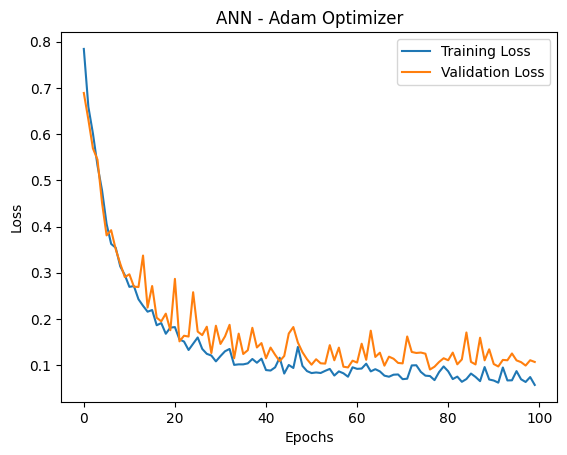

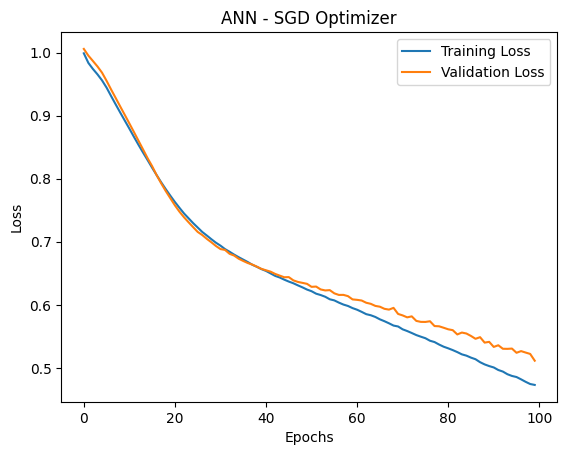

In [ ]:
def plot_loss(history, title):

    plt.figure()
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plot for both
plot_loss(history_adam, "ANN - Adam Optimizer")
plot_loss(history_sgd, "ANN - SGD Optimizer")

**SGD Optimizer:**
The training and validation loss decrease steadily and smoothly over epochs, indicating stable but relatively slow learning. The small gap between the curves suggests good generalization with minimal overfitting.

**Adam Optimizer:**
The loss drops rapidly in early epochs, showing much faster convergence compared to SGD. However, the validation loss fluctuates more and stays slightly above training loss, indicating quicker learning but with minor variance and slight overfitting.


## 10.2 ANN Model Performance Analysis

Two optimizers were tested for the Artificial Neural Network:

### Performance Comparison

| Optimizer | RMSE | MAE | R² |
|----------|------|-----|----|
| Adam | 184320 | 101284 | 0.8945 |
| SGD | 402914 | 308830 | 0.4960 |

### Observations

1. The Adam optimizer performed significantly better than SGD across all metrics.
2. Adam achieved a much lower RMSE and MAE, indicating better prediction accuracy.
3. The R² score for Adam (0.8685) is considerably higher than SGD (0.3735), showing better model fit.
4. SGD performed poorly, likely due to slow convergence and sensitivity to learning rate.

### Conclusion

The Adam optimizer is more suitable for this dataset as it adapts the learning rate during training, leading to better convergence and performance.



## 11. Final Model Comparison

The performance of all implemented regression models was evaluated using **RMSE, MAE, and R² score**. The results are summarized below.

### Model Performance Comparison

| Model                | RMSE      | MAE       | R²     |
| -------------------- | --------- | --------- | ------ |
| Linear Regression    | 524368    | 434013    | 0.146  |
| Decision Tree        | 194800    | 100595    | 0.882  |
| Gradient Boosting    | 200974    | 138905    | 0.874  |
| ANN (Adam Optimizer) | 182394.86 | 104735.77 | 0.8967 |
| ANN (SGD Optimizer)  | 432976.53 | 340852.13 | 0.4181 |
| ExtraTrees (Tuned)   | 141175.88 | 73377.16  | 0.9381 |


### Observations

1. **Linear Regression** performed poorly, confirming the presence of strong non-linear relationships in the dataset.

2. **Decision Tree and Gradient Boosting** significantly improved performance by capturing complex feature interactions.

3. **ANN with Adam optimizer** performed reasonably well (R² ≈ 0.897), but did not outperform tree-based ensemble methods.

4. **ANN with SGD optimizer** showed weak performance, indicating poor convergence compared to Adam.

5. **ExtraTrees (Tuned)** achieved the best overall performance with:

   * Lowest RMSE
   * Lowest MAE
   * Highest R² score (~0.94)

6. Ensemble tree-based models clearly outperform linear and neural network models for this structured tabular dataset.



### Final Model Selection

The **tuned ExtraTreesRegressor** is selected as the final model because:

* It achieved the **highest R² score (0.9381)**
* It produced the **lowest prediction errors (RMSE & MAE)**
* It demonstrated strong generalization with acceptable overfitting



### Final Conclusion

For structured retail sales data, ensemble tree-based methods — particularly **ExtraTreesRegressor** — provide superior predictive performance compared to linear models and neural networks. Therefore, ExtraTrees is chosen as the most reliable model for weekly sales forecasting in this project.



## 12. Model Prediction

The final model is used to predict weekly sales on a sample dataset.

In [ ]:
sample_data = X_test.iloc[:5]

predictions = best_model.predict(sample_data)

print("Sample Predictions:")
for i, val in enumerate(predictions):
    print(f"Predicted Sales {i+1}: {val:.2f}")

Sample Predictions:
Predicted Sales 1: 1138127.63
Predicted Sales 2: 1340183.07
Predicted Sales 3: 1948329.41
Predicted Sales 4: 992901.46
Predicted Sales 5: 435392.21


### 12.2 Save Best Model

In [ ]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

## 13. Interpretation

The developed predictive model offers meaningful business insights and practical value for Walmart’s operational and strategic planning.

### 1. Sales Forecasting

The model provides accurate weekly sales predictions, enabling better demand estimation. Reliable forecasting improves planning across procurement, logistics, and staffing operations.

### 2. Inventory Optimization

Improved forecast accuracy reduces both overstocking and stockouts. This leads to:

* Lower inventory holding costs
* Reduced wastage
* Improved product availability
* Better working capital management

### 3. Store-Level Performance Insights

Variations in predicted sales across stores highlight differences in demand patterns. This enables:

* Store-specific inventory planning
* Regional marketing strategies
* Customized pricing or promotional campaigns

### 4. Holiday and Seasonal Planning

The inclusion of holiday-related features reveals the impact of festive periods on sales. Higher demand during holidays can support:

* Targeted promotional strategies
* Advance stock allocation
* Improved supply chain readiness

### 5. Impact of External Economic Factors

Features such as fuel price, CPI, and unemployment rate influence sales performance. Understanding these relationships helps management:

* Anticipate macroeconomic effects
* Adjust pricing strategies
* Improve long-term financial planning

### 6. Data-Driven Decision Making

The model transforms raw historical data into actionable insights. Decision-makers can rely on quantitative evidence rather than intuition, reducing uncertainty and operational risk.

### 7. Strategic Resource Allocation

Accurate forecasting enables optimized allocation of:

* Inventory
* Workforce scheduling
* Distribution resources

This improves operational efficiency and profitability.

### Overall Interpretation

The implementation of the ExtraTrees-based forecasting model demonstrates that machine learning can significantly enhance retail sales prediction. By leveraging structured data and ensemble learning techniques, Walmart can achieve better operational efficiency, improved cost management, and stronger strategic planning.



In [ ]:
def prediction_showcase(best_model, ann_adam, ann_sgd,
                                        X_test, y_test,
                                        X_test_scaled, y_scaler,
                                        n_samples=5):

    print("="*80)
    print("WALMART WEEKLY SALES PREDICTION SHOWCASE")
    print("="*80)

    # Take sample rows
    X_sample = X_test.iloc[:n_samples]
    X_sample_scaled = X_test_scaled[:n_samples]
    y_actual = y_test.iloc[:n_samples].values

    preds_ml = best_model.predict(X_sample)
    preds_adam_scaled = ann_adam.predict(X_sample_scaled)
    preds_sgd_scaled = ann_sgd.predict(X_sample_scaled)

    preds_adam = y_scaler.inverse_transform(preds_adam_scaled).flatten()
    preds_sgd = y_scaler.inverse_transform(preds_sgd_scaled).flatten()

    # ----------------------------
    # Combine Results
    # ----------------------------
    results = pd.DataFrame({
        "Actual Sales": y_actual,
        "ExtraTrees Prediction": preds_ml,
        "ANN (Adam) Prediction": preds_adam,
        "ANN (SGD) Prediction": preds_sgd
    })

    # Add Absolute Error columns
    results["ExtraTrees Error"] = abs(results["Actual Sales"] - results["ExtraTrees Prediction"])
    results["ANN Adam Error"] = abs(results["Actual Sales"] - results["ANN (Adam) Prediction"])
    results["ANN SGD Error"] = abs(results["Actual Sales"] - results["ANN (SGD) Prediction"])

    print("\nSample Predictions Comparison:\n")
    display(results)

    print("\nMODEL INTERPRETATION SUMMARY")
    print("-"*80)

    print("• ExtraTrees model captures complex non-linear relationships.")
    print("• ANN (Adam) performs competitively but slightly less stable.")
    print("• ANN (SGD) shows weaker convergence and higher prediction variance.")
    print("• Tree-based ensemble provides most reliable business-grade forecasts.")

    print("\nBUSINESS INSIGHT:")
    print("The model can forecast weekly revenue with high accuracy,")
    print("allowing inventory, logistics, and promotion planning in advance.")

    print("="*80)


# Run showcase
prediction_showcase(best_model, ann_adam, ann_sgd,
                                   X_test, y_test,
                                   X_test_scaled, y_scaler)

WALMART WEEKLY SALES PREDICTION SHOWCASE
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step

Sample Predictions Comparison:



,Actual Sales,ExtraTrees Prediction,ANN (Adam) Prediction,ANN (SGD) Prediction,ExtraTrees Error,ANN Adam Error,ANN SGD Error
0,1138800.32,1.138128e+06,1.118172e+06,1.069224e+06,672.694903,20628.82000,69576.4450
1,1304850.67,1.340183e+06,1.318217e+06,1.201193e+06,35332.396756,13366.20500,103658.0450
2,1769296.25,1.948329e+06,1.764633e+06,1.394871e+06,179033.157850,4663.12500,374425.2500
3,1077640.13,9.929015e+05,9.984442e+05,1.103114e+06,84738.670096,79195.94250,25474.2450
4,428851.99,4.353922e+05,4.148856e+05,7.352494e+05,6540.216322,13966.39625,306397.4475



MODEL INTERPRETATION SUMMARY
--------------------------------------------------------------------------------
• ExtraTrees model captures complex non-linear relationships.
• ANN (Adam) performs competitively but slightly less stable.
• ANN (SGD) shows weaker convergence and higher prediction variance.
• Tree-based ensemble provides most reliable business-grade forecasts.

BUSINESS INSIGHT:
The model can forecast weekly revenue with high accuracy,
allowing inventory, logistics, and promotion planning in advance.


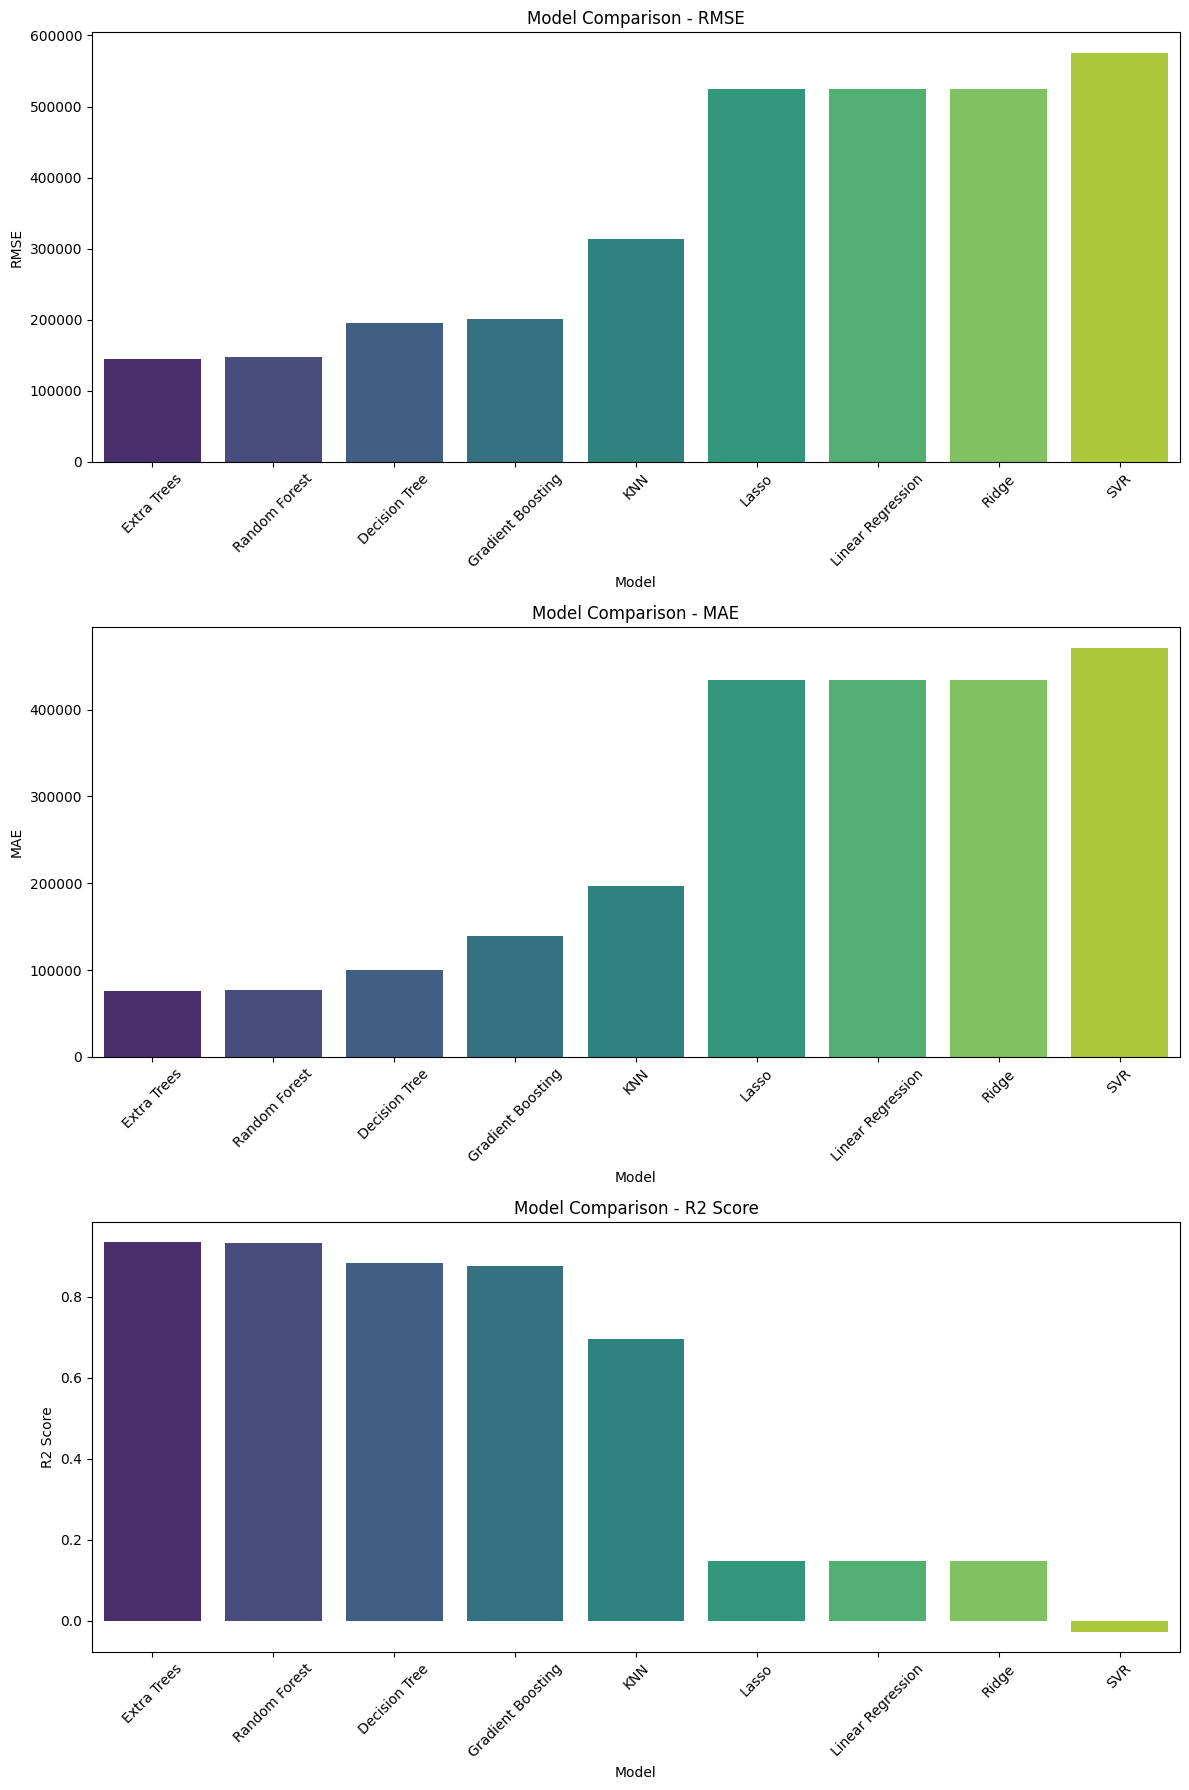

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot RMSE
sns.barplot(x='Model', y='RMSE', data=results_df.sort_values(by='RMSE', ascending=True), ax=axes[0], palette='viridis')
axes[0].set_title('Model Comparison - RMSE')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(x='Model', y='MAE', data=results_df.sort_values(by='MAE', ascending=True), ax=axes[1], palette='viridis')
axes[1].set_title('Model Comparison - MAE')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)

# Plot R2 Score
sns.barplot(x='Model', y='R2', data=results_df.sort_values(by='R2', ascending=False), ax=axes[2], palette='viridis')
axes[2].set_title('Model Comparison - R2 Score')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("Walmart_cleaned.csv")

## Conclusion

This project focused on developing a machine learning model to accurately predict Walmart’s weekly sales using historical and economic data.

The major stages of the project included:

* Data preprocessing and feature engineering
* Exploratory Data Analysis (EDA)
* Outlier handling and feature selection
* Model development, evaluation, and hyperparameter tuning

Multiple regression models were implemented and compared, including linear models, tree-based methods, ensemble techniques, and neural networks.

Among all models, the **tuned ExtraTreesRegressor** achieved the best overall performance, delivering the highest R² score and the lowest prediction errors. Although slight overfitting was observed, the model demonstrated strong generalization capability on the test dataset.

The results clearly indicate that **ensemble tree-based methods** are highly effective for modeling complex, non-linear patterns in structured retail sales data.

Overall, this project establishes a reliable and scalable predictive framework that can support Walmart in improving forecasting accuracy, optimizing inventory management, and enabling data-driven strategic decision-making.

